In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('outputs', exist_ok=True)

In [2]:
df = pd.read_csv("joined_data.csv")
df.head()

,observation_date,A191RL1Q225SBEA,UNRATE,CUSR0000SAC
0,1956-01-01,-1.5,4.033333,31.166667
1,1956-04-01,3.3,4.200000,31.400000
2,1956-07-01,-0.3,4.133333,31.766667
3,1956-10-01,6.8,4.133333,32.033333
4,1957-01-01,2.6,3.933333,32.233333


In [3]:
#creating dummy vars for covid spikes
covid_quarters = ['2020-04-01', '2020-07-01']

df['covid_dummy'] = df['observation_date'].isin(covid_quarters).astype(int)
df[df['covid_dummy'] == 1]

,observation_date,A191RL1Q225SBEA,UNRATE,CUSR0000SAC,covid_dummy
257,2020-04-01,-28.0,13.0,181.834000,1
258,2020-07-01,34.9,8.8,184.818333,1


In [4]:
# renaming columns 
df = df.rename(columns={
    'A191RL1Q225SBEA': 'gdp_growth_rate',
    'CUSR0000SAC': 'cpi_commodities',
    'UNRATE': 'unemployment_rate'
})
df.head()

,observation_date,gdp_growth_rate,unemployment_rate,cpi_commodities,covid_dummy
0,1956-01-01,-1.5,4.033333,31.166667,0
1,1956-04-01,3.3,4.200000,31.400000,0
2,1956-07-01,-0.3,4.133333,31.766667,0
3,1956-10-01,6.8,4.133333,32.033333,0
4,1957-01-01,2.6,3.933333,32.233333,0


In [5]:
# specifying X and Y for later models 
X = df[['gdp_growth_rate', 'cpi_commodities', 'covid_dummy']]
y = df['unemployment_rate']

                   gdp_growth_rate  unemployment_rate  cpi_commodities
gdp_growth_rate           1.000000          -0.083249        -0.117381
unemployment_rate        -0.083249           1.000000        -0.008250
cpi_commodities          -0.117381          -0.008250         1.000000


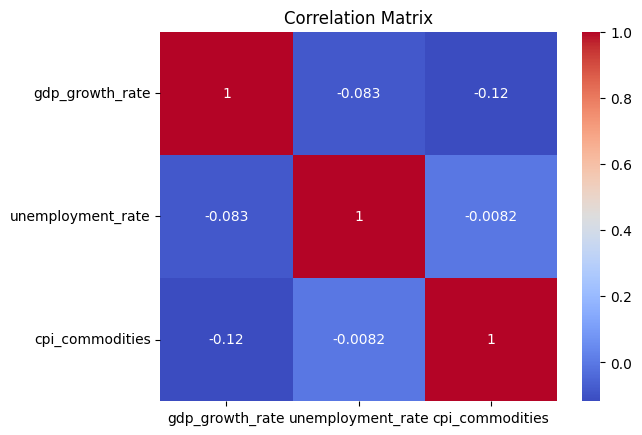

In [6]:
corr = df[['gdp_growth_rate', 'unemployment_rate', 'cpi_commodities']].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('outputs/correlation_matrix.png')
plt.show()

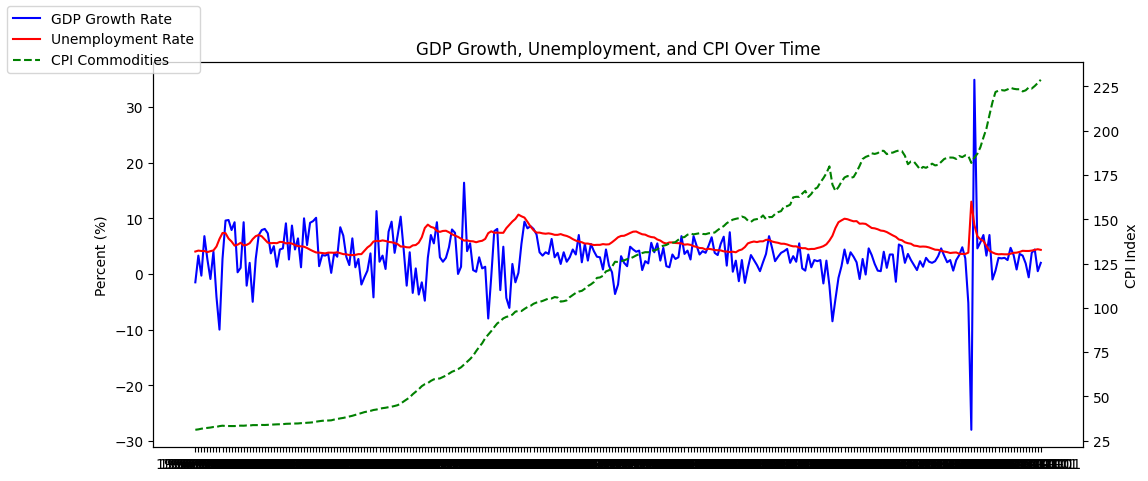

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df['observation_date'], df['gdp_growth_rate'], label='GDP Growth Rate', color='blue')
ax1.plot(df['observation_date'], df['unemployment_rate'], label='Unemployment Rate', color='red')
ax1.set_ylabel('Percent (%)')

ax2 = ax1.twinx()
ax2.plot(df['observation_date'], df['cpi_commodities'], label='CPI Commodities', color='green', linestyle='--')
ax2.set_ylabel('CPI Index')

fig.legend(loc='upper left')
plt.title('GDP Growth, Unemployment, and CPI Over Time')
plt.savefig('outputs/timeseries.png')
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error

# baseline model with just simple mean
y_pred_baseline = np.full(len(y), y.mean())

rmse_baseline = np.sqrt(mean_squared_error(y, y_pred_baseline))

print(f'Baseline Mean Prediction: {y.mean():.4f}')
print(f'Baseline RMSE: {rmse_baseline:.4f}')

Baseline Mean Prediction: 5.8188
Baseline RMSE: 1.6673


In [9]:
#save new csv
df.to_csv("joined_data.csv", index=False)